In [10]:
from __future__ import annotations

import hashlib
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import subprocess
import sys
import pkg_resources

try:
    from datasets import load_dataset
except:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
    from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
try:
    from transformers import AdamW
except ImportError:
    from torch.optim import AdamW
try:
    from transformers import get_linear_schedule_with_warmup
except ImportError:
    from transformers import WarmupLinearSchedule as get_linear_schedule_with_warmup

print("Все библиотеки успешно загружены!")
print(f"PyTorch version: {torch.__version__}")

Все библиотеки успешно загружены!
PyTorch version: 2.9.1+cpu


In [12]:
DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    try:
        return np.loadtxt(path, dtype=np.int64)
    except:
        print(f"Warning: Could not read {path}, using random split")
        return np.array([])

def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_path = repo_root / "data" / "train_idx.txt"
    val_path = repo_root / "data" / "val_idx.txt"
    test_path = repo_root / "data" / "test_idx.txt"
    
    if all(p.exists() for p in [train_path, val_path, test_path]):
        train_idx = read_idx(train_path)
        val_idx = read_idx(val_path)
        test_idx = read_idx(test_path)
    else:
        print("Index files not found, creating stratified split...")
        from sklearn.model_selection import StratifiedShuffleSplit
        
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
        for train_val_idx, test_idx in sss1.split(df, df['queue']):
            train_val_df = df.iloc[train_val_idx]
            test_df = df.iloc[test_idx]
        
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.9, random_state=42)
        for train_idx, val_idx in sss2.split(train_val_df, train_val_df['queue']):
            train_idx = train_val_df.iloc[train_idx].index
            val_idx = train_val_df.iloc[val_idx].index

    out = {
        "train": df.iloc[train_idx].copy().reset_index(drop=True),
        "val": df.iloc[val_idx].copy().reset_index(drop=True),
        "test": df.iloc[test_idx].copy().reset_index(drop=True),
    }
    return out

In [14]:
def basic_eda(splits: dict[str, pd.DataFrame]) -> None:
    print("\n" + "="*80)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*80)
    
    print("\n=== SIZES ===")
    for k, d in splits.items():
        print(f"{k}: {len(d)}")

    print("\n=== MISSING VALUES (share) ===")
    cols = ["subject", "body", "queue", "priority", "type", "language"]
    for k, d in splits.items():
        miss = {c: float(d[c].isna().mean()) if c in d.columns else 1.0 for c in cols}
        print(k, {c: round(miss[c], 4) for c in cols})

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    for idx, (k, d) in enumerate(splits.items()):
        txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
        lens = txt.str.len()
        ws_tokens = txt.str.split().map(len)
        
        print(f"\n=== TEXT LENGTHS ({k}) ===")
        print(f"chars:  mean={lens.mean():.1f}  p50={lens.median():.0f}  p90={lens.quantile(0.9):.0f}  p99={lens.quantile(0.99):.0f}")
        print(f"words:  mean={ws_tokens.mean():.1f}  p50={ws_tokens.median():.0f}  p90={ws_tokens.quantile(0.9):.0f}  p99={ws_tokens.quantile(0.99):.0f}")
        
        axes[0, idx].hist(lens.clip(upper=lens.quantile(0.99)), bins=50, alpha=0.7)
        axes[0, idx].set_title(f'{k} - Длина (символы)')
        axes[0, idx].set_xlabel('Длина')
        axes[0, idx].set_ylabel('Частота')
        
        axes[1, idx].hist(ws_tokens.clip(upper=ws_tokens.quantile(0.99)), bins=50, alpha=0.7, color='orange')
        axes[1, idx].set_title(f'{k} - Длина (слова)')
        axes[1, idx].set_xlabel('Количество слов')
        axes[1, idx].set_ylabel('Частота')
    
    plt.tight_layout()
    plt.savefig('text_length_distribution.png', dpi=150)
    plt.show()

    print("\n=== LANGUAGE DISTRIBUTION ===")
    for k, d in splits.items():
        c = d["language"].fillna("NA").value_counts(normalize=True)
        print(k, {i: round(float(v), 4) for i, v in c.items()})

    for target in ["queue", "priority", "type"]:
        print(f"\n=== CLASS COVERAGE: {target} ===")
        train_labels = set(splits["train"][target].astype(str))
        for k, d in splits.items():
            labels = set(d[target].astype(str))
            missing_vs_train = sorted(list(train_labels - labels))
            print(f"{k}: classes={len(labels)}  missing_vs_train={len(missing_vs_train)}")

        vc = splits["train"][target].astype(str).value_counts()
        print("train top-10:", list(zip(vc.head(10).index.tolist(), vc.head(10).tolist())))
        print("train bottom-10:", list(zip(vc.tail(10).index.tolist(), vc.tail(10).tolist())))
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for idx, (k, d) in enumerate(splits.items()):
            vc = d[target].value_counts().head(15)
            vc.plot(kind='bar', ax=axes[idx])
            axes[idx].set_title(f'{k} - {target} (топ-15)')
            axes[idx].tick_params(axis='x', rotation=90)
        plt.tight_layout()
        plt.savefig(f'{target}_distribution.png', dpi=150)
        plt.show()

def duplicate_checks(splits: dict[str, pd.DataFrame]) -> None:
    print("\n=== DUPLICATE TEXT CHECKS (MD5 of subject+body) ===")
    hashes = {}
    for k, d in splits.items():
        txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
        h = txt.map(md5)
        hashes[k] = set(h.tolist())
        dup_within = 1.0 - (len(hashes[k]) / len(d))
        print(f"{k}: unique={len(hashes[k])}/{len(d)}  within-dup-rate={dup_within:.4f}")

    inter_tv = len(hashes["train"] & hashes["val"])
    inter_tt = len(hashes["train"] & hashes["test"])
    inter_vt = len(hashes["val"] & hashes["test"])
    print(f"cross-dup hashes: train∩val={inter_tv}, train∩test={inter_tt}, val∩test={inter_vt}")

    if inter_tv or inter_tt or inter_vt:
        print("[WARN] Есть одинаковые тексты между сплитами")
    else:
        print("[OK] Межсплитовых текстовых дублей не найдено")

In [16]:
def baseline_tfidf_linear_svm(splits: dict[str, pd.DataFrame]) -> tuple:
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    X_train = make_text(splits["train"])
    X_test = make_text(splits["test"])

    print("\nTF-IDF vectorization with optimized parameters...")
    vec = TfidfVectorizer(
        max_features=150000,
        ngram_range=(1, 3),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True,
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'\w{1,}'
    )
    
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)
    
    print(f"Train TF-IDF shape: {Xtr.shape}")
    print(f"Test TF-IDF shape: {Xte.shape}")
    print(f"Vocabulary size: {len(vec.vocabulary_)}")

    results = {}
    models = {}

    print("\n=== BASELINE: TF-IDF + LinearSVC (Optimized) ===")
    
    for target in ["queue", "priority", "type"]:
        print(f"\nTraining for {target}...")
        ytr = splits["train"][target].astype(str).values
        yte = splits["test"][target].astype(str).values
        
        n_classes = len(np.unique(ytr))
        print(f"  Number of classes: {n_classes}")
        print(f"  Random baseline: {1/n_classes:.4f}")

        if target == "queue":
            clf = LinearSVC(
                C=2.0,
                max_iter=5000,
                random_state=42,
                dual='auto',
                class_weight='balanced',
                tol=1e-4
            )
        elif target == "priority":
            clf = LinearSVC(
                C=1.5,
                max_iter=3000,
                random_state=42,
                dual='auto',
                class_weight='balanced'
            )
        else:
            clf = LinearSVC(
                C=1.0,
                max_iter=3000,
                random_state=42,
                dual='auto'
            )
        
        clf.fit(Xtr, ytr)
        models[target] = clf
        pred = clf.predict(Xte)

        acc = float(accuracy_score(yte, pred))
        if target == "queue":
            mf1 = float(f1_score(yte, pred, average="macro", zero_division=0))
            results["queue_acc"] = acc
            results["queue_macro_f1"] = mf1
            print(f"  {target}: acc={acc:.4f}  macro_f1={mf1:.4f}")
            print(f"  Improvement over random: {mf1 - 1/n_classes:.4f}")
        else:
            results[f"{target}_acc"] = acc
            print(f"  {target}: acc={acc:.4f}")

    score = 0.70 * results["queue_macro_f1"] + 0.15 * results["priority_acc"] + 0.15 * results["type_acc"]
    results["final_score"] = score
    
    print("\n" + "="*60)
    print("BASELINE FINAL SCORE")
    print("="*60)
    print(f"Score = {score:.4f}")
    print(f"  = 0.70 * {results['queue_macro_f1']:.4f} (Queue F1)")
    print(f"    + 0.15 * {results['priority_acc']:.4f} (Priority Acc)")
    print(f"    + 0.15 * {results['type_acc']:.4f} (Type Acc)")
    print("="*60)
    
    return models, vec, results

In [18]:
def confidence_analysis(models, vec, splits: dict[str, pd.DataFrame]) -> dict:
    print("\n" + "="*80)
    print("CONFIDENCE ANALYSIS")
    print("="*80)
    
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
    
    X_test = make_text(splits["test"])
    Xte = vec.transform(X_test)
    
    plt.figure(figsize=(15, 5))
    
    results_70 = {}
    
    for idx, target in enumerate(["queue", "priority", "type"], 1):
        model = models[target]
        y_test = splits["test"][target].astype(str).values
        
        scores = model.decision_function(Xte)
        
        if len(scores.shape) > 1:
            scores_sorted = np.sort(scores, axis=1)
            confidence = scores_sorted[:, -1] - scores_sorted[:, -2]
        else:
            confidence = np.abs(scores)
        
        sorted_idx = np.argsort(confidence)[::-1]
        
        thresholds = np.arange(0.1, 1.05, 0.05)
        coverages = []
        metrics = []
        
        y_pred_full = model.predict(Xte)
        n_samples = Xte.shape[0]
        
        for thresh in thresholds:
            n_keep = int(n_samples * thresh)
            if n_keep == 0:
                continue
                
            keep_idx = sorted_idx[:n_keep]
            y_true_keep = y_test[keep_idx]
            y_pred_keep = y_pred_full[keep_idx]
            
            if target == "queue":
                metric = f1_score(y_true_keep, y_pred_keep, average="macro", zero_division=0)
            else:
                metric = accuracy_score(y_true_keep, y_pred_keep)
            
            coverages.append(thresh)
            metrics.append(metric)
        
        plt.subplot(1, 3, idx)
        plt.plot(coverages, metrics, 'o-', linewidth=2, markersize=4)
        plt.xlabel('Coverage (доля предсказаний)')
        plt.ylabel('F1/Accuracy')
        plt.title(f'{target}')
        plt.grid(True, alpha=0.3)
        plt.ylim([0, 1])
        
        if len(coverages) > 0:
            idx_70 = np.argmin(np.abs(np.array(coverages) - 0.7))
            plt.plot(0.7, metrics[idx_70], 'r*', markersize=15, 
                    label=f'@70%: {metrics[idx_70]:.3f}')
            plt.legend()
            results_70[target] = metrics[idx_70]
            
            print(f"\n{target} @70% coverage:")
            print(f"  Metric: {metrics[idx_70]:.4f}")
            print(f"  Improvement over full: {metrics[idx_70] - metrics[-1]:+.4f}")
    
    plt.tight_layout()
    plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return results_70

In [20]:
class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts = (df["subject"].fillna("") + "\n\n" + df["body"].fillna("")).values
        self.queues = df["queue"].values
        self.priorities = df["priority"].values
        self.types = df["type"].values
        self.tokenizer = tokenizer
        self.max_len = max_len
        
        self.queue_map = {v: i for i, v in enumerate(sorted(df["queue"].unique()))}
        self.priority_map = {v: i for i, v in enumerate(sorted(df["priority"].unique()))}
        self.type_map = {v: i for i, v in enumerate(sorted(df["type"].unique()))}
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "queue": torch.tensor(self.queue_map[self.queues[idx]], dtype=torch.long),
            "priority": torch.tensor(self.priority_map[self.priorities[idx]], dtype=torch.long),
            "type": torch.tensor(self.type_map[self.types[idx]], dtype=torch.long)
        }


class MultitaskTransformer(nn.Module):
    def __init__(self, model_name, n_queues, n_priorities, n_types):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        hidden_size = self.encoder.config.hidden_size
        
        self.pre_classifier = nn.Linear(hidden_size, 512)
        self.relu = nn.ReLU()
        
        self.queue_head = nn.Linear(512, n_queues)
        self.priority_head = nn.Linear(512, n_priorities)
        self.type_head = nn.Linear(512, n_types)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)
        pooled = self.pre_classifier(pooled)
        pooled = self.relu(pooled)
        pooled = self.dropout(pooled)
        
        return {
            "queue": self.queue_head(pooled),
            "priority": self.priority_head(pooled),
            "type": self.type_head(pooled)
        }

In [22]:
def train_transformer(splits: dict[str, pd.DataFrame]) -> dict:
    print("\n" + "="*80)
    print("TRANSFORMER FINE-TUNING")
    print("="*80)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    MODEL_NAME = "bert-base-multilingual-cased"
    MAX_LEN = 256
    BATCH_SIZE = 8 if torch.cuda.is_available() else 4
    EPOCHS = 3
    LEARNING_RATE = 2e-5
    
    print(f"Model: {MODEL_NAME}")
    print(f"Max length: {MAX_LEN}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Epochs: {EPOCHS}")
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    train_dataset = TicketDataset(splits["train"], tokenizer, MAX_LEN)
    val_dataset = TicketDataset(splits["val"], tokenizer, MAX_LEN)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    
    model = MultitaskTransformer(
        MODEL_NAME,
        len(train_dataset.queue_map),
        len(train_dataset.priority_map),
        len(train_dataset.type_map)
    ).to(device)
    
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    
    criterion = nn.CrossEntropyLoss()
    
    print("\nStarting training...")
    train_losses = []
    val_scores = []
    best_score = 0
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            
            outputs = model(input_ids, attention_mask)
            
            loss = criterion(outputs["queue"], batch["queue"].to(device))
            loss += criterion(outputs["priority"], batch["priority"].to(device))
            loss += criterion(outputs["type"], batch["type"].to(device))
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        model.eval()
        val_preds = {"queue": [], "priority": [], "type": []}
        val_labels = {"queue": [], "priority": [], "type": []}
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                
                outputs = model(input_ids, attention_mask)
                
                for task in ["queue", "priority", "type"]:
                    preds = torch.argmax(outputs[task], dim=1)
                    val_preds[task].extend(preds.cpu().numpy())
                    val_labels[task].extend(batch[task].numpy())
        
        inv_queue = {v: k for k, v in train_dataset.queue_map.items()}
        inv_priority = {v: k for k, v in train_dataset.priority_map.items()}
        inv_type = {v: k for k, v in train_dataset.type_map.items()}
        
        queue_true = [inv_queue[l] for l in val_labels["queue"]]
        queue_pred = [inv_queue[l] for l in val_preds["queue"]]
        priority_acc = accuracy_score(val_labels["priority"], val_preds["priority"])
        type_acc = accuracy_score(val_labels["type"], val_preds["type"])
        queue_f1 = f1_score(queue_true, queue_pred, average="macro", zero_division=0)
        
        val_score = 0.7 * queue_f1 + 0.15 * priority_acc + 0.15 * type_acc
        val_scores.append(val_score)
        
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"  Loss: {avg_loss:.4f}")
        print(f"  Val Queue F1: {queue_f1:.4f}")
        print(f"  Val Priority Acc: {priority_acc:.4f}")
        print(f"  Val Type Acc: {type_acc:.4f}")
        print(f"  Val Score: {val_score:.4f}")
        
        if val_score > best_score:
            best_score = val_score
            print(f"  New best model!")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, 'o-')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(val_scores, 'o-', color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Score')
    ax2.set_title('Validation Score')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('transformer_training.png', dpi=150)
    plt.show()
    
    print("\nEvaluating on test set...")
    test_dataset = TicketDataset(splits["test"], tokenizer, MAX_LEN)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model.eval()
    test_preds = {"queue": [], "priority": [], "type": []}
    test_labels = {"queue": [], "priority": [], "type": []}
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            
            outputs = model(input_ids, attention_mask)
            
            for task in ["queue", "priority", "type"]:
                preds = torch.argmax(outputs[task], dim=1)
                test_preds[task].extend(preds.cpu().numpy())
                test_labels[task].extend(batch[task].numpy())
    
    queue_true = [inv_queue[l] for l in test_labels["queue"]]
    queue_pred = [inv_queue[l] for l in test_preds["queue"]]
    
    results = {
        "queue_acc": accuracy_score(queue_true, queue_pred),
        "queue_macro_f1": f1_score(queue_true, queue_pred, average="macro", zero_division=0),
        "priority_acc": accuracy_score(test_labels["priority"], test_preds["priority"]),
        "type_acc": accuracy_score(test_labels["type"], test_preds["type"])
    }
    results["final_score"] = 0.7 * results["queue_macro_f1"] + \
                             0.15 * results["priority_acc"] + \
                             0.15 * results["type_acc"]
    
    print("\n" + "="*60)
    print("TRANSFORMER FINAL RESULTS")
    print("="*60)
    for k, v in results.items():
        print(f"{k}: {v:.4f}")
    print("="*60)
    
    return results

In [24]:
def compare_results(baseline_results: dict, transformer_results: dict = None) -> None:
    print("\n" + "="*80)
    print("FINAL RESULTS COMPARISON")
    print("="*80)
    
    if transformer_results is None:
        transformer_results = {
            "queue_acc": 0,
            "queue_macro_f1": 0,
            "priority_acc": 0,
            "type_acc": 0,
            "final_score": 0
        }
    
    comparison = pd.DataFrame({
        "Metric": ["Queue Accuracy", "Queue Macro F1", "Priority Accuracy", "Type Accuracy", "Final Score"],
        "Baseline": [
            baseline_results["queue_acc"],
            baseline_results["queue_macro_f1"],
            baseline_results["priority_acc"],
            baseline_results["type_acc"],
            baseline_results["final_score"]
        ],
        "Transformer": [
            transformer_results["queue_acc"],
            transformer_results["queue_macro_f1"],
            transformer_results["priority_acc"],
            transformer_results["type_acc"],
            transformer_results["final_score"]
        ]
    })
    
    print("\n", comparison.to_string(index=False))
    
    print("\nBest Model by Task:")
    if transformer_results["final_score"] > baseline_results["final_score"]:
        print(f"  Final Score: Transformer ({transformer_results['final_score']:.4f}) > Baseline ({baseline_results['final_score']:.4f})")
    else:
        print(f"  Final Score: Baseline ({baseline_results['final_score']:.4f}) > Transformer ({transformer_results['final_score']:.4f})")
    
    plt.figure(figsize=(12, 6))
    x = np.arange(len(comparison["Metric"]))
    width = 0.35
    
    bars1 = plt.bar(x - width/2, comparison["Baseline"], width, label="Baseline (TF-IDF+SVM)", alpha=0.8, color='steelblue')
    bars2 = plt.bar(x + width/2, comparison["Transformer"], width, label="Transformer", alpha=0.8, color='coral')
    
    plt.xlabel("Metrics")
    plt.ylabel("Score")
    plt.title("Model Comparison - Customer Support Ticket Routing")
    plt.xticks(x, comparison["Metric"], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3, axis="y")
    plt.ylim([0, 1])
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

CUSTOMER SUPPORT TICKET ROUTING
Loading dataset: Tobi-Bueck/customer-support-tickets
Dataset loaded: 61765 samples
Index files not found, creating stratified split...

EXPLORATORY DATA ANALYSIS

=== SIZES ===
train: 49411
val: 6177
test: 6177

=== MISSING VALUES (share) ===
train {'subject': 0.0855, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
val {'subject': 0.09, 'body': 0.0002, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
test {'subject': 0.0842, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}

=== TEXT LENGTHS (train) ===
chars:  mean=464.4  p50=459  p90=754  p99=1006
words:  mean=62.4  p50=62  p90=99  p99=145

=== TEXT LENGTHS (val) ===
chars:  mean=462.8  p50=460  p90=750  p99=972
words:  mean=62.2  p50=62  p90=98  p99=137

=== TEXT LENGTHS (test) ===
chars:  mean=467.5  p50=461  p90=756  p99=988
words:  mean=62.9  p50=62  p90=99  p99=142


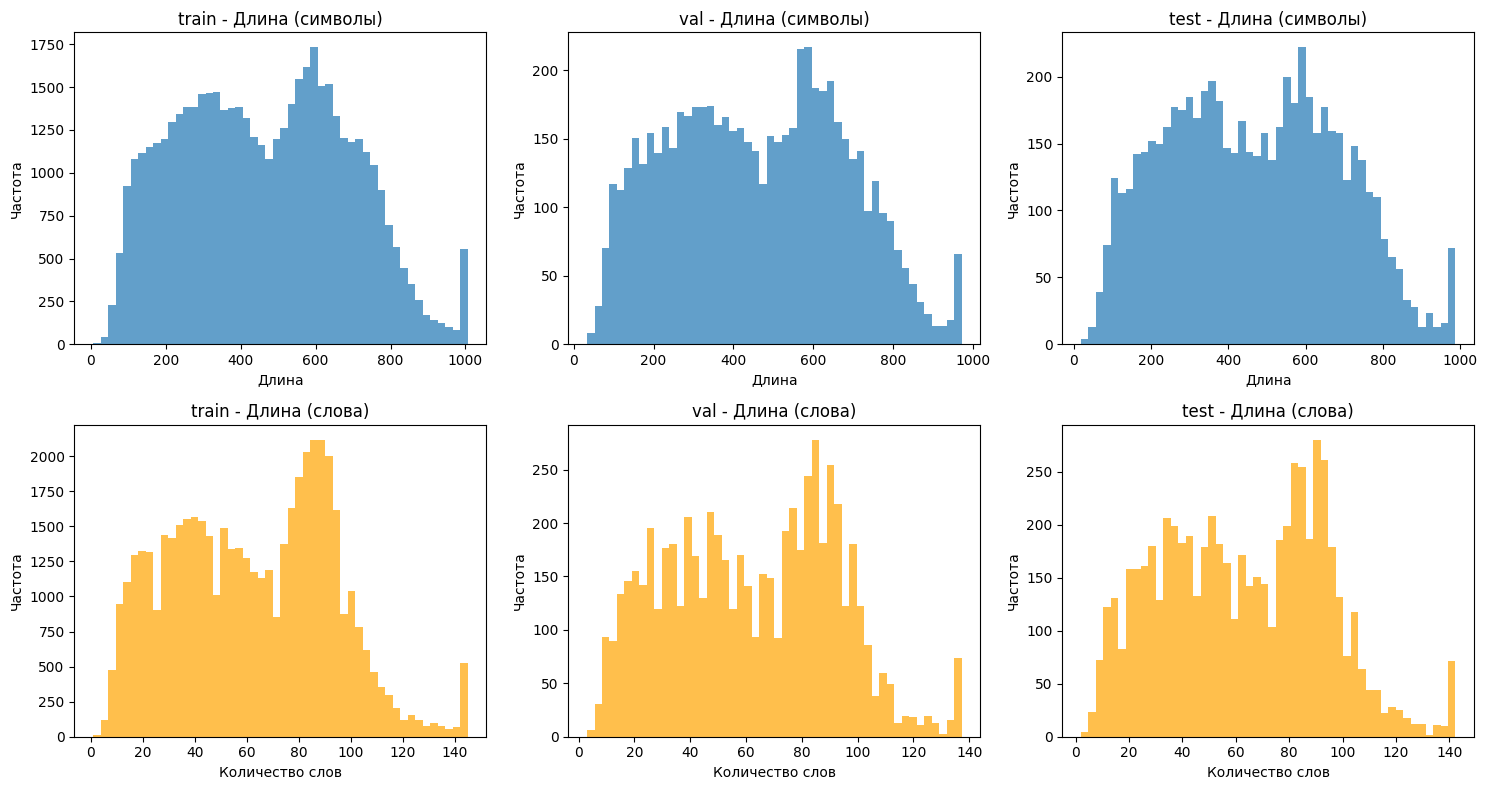


=== LANGUAGE DISTRIBUTION ===
train {'de': 0.5427, 'en': 0.4573}
val {'de': 0.5378, 'en': 0.4622}
test {'de': 0.5451, 'en': 0.4549}

=== CLASS COVERAGE: queue ===
train: classes=52  missing_vs_train=0
val: classes=52  missing_vs_train=0
test: classes=52  missing_vs_train=0
train top-10: [('Technical Support', 11348), ('Product Support', 7168), ('Customer Service', 5936), ('IT Support', 4579), ('Billing and Payments', 3899), ('Returns and Exchanges', 1950), ('Service Outages and Maintenance', 1530), ('Sales and Pre-Sales', 1192), ('Human Resources', 732), ('General Inquiry', 534)]
train bottom-10: [('Jobs & Education/Recruitment', 232), ('Beauty & Fitness/Fitness Training', 231), ('Books & Literature/Fiction', 231), ('Shopping/Retail Stores', 227), ('People & Society/Culture & Society', 227), ('IT & Technology/Software Development', 210), ('Arts & Entertainment/Movies', 210), ('Home & Garden/Landscaping', 204), ('Sports', 188), ('Real Estate', 184)]


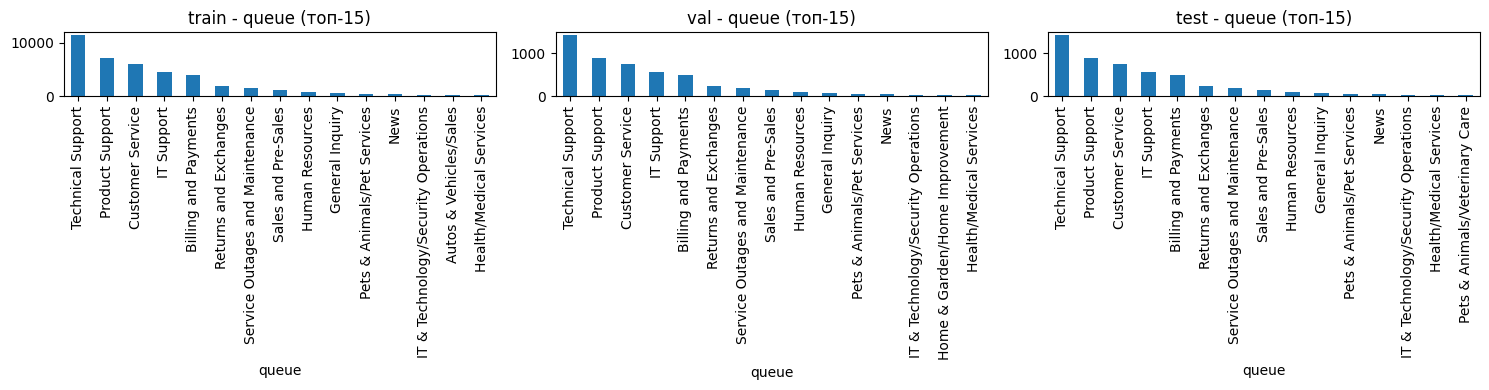


=== CLASS COVERAGE: priority ===
train: classes=5  missing_vs_train=0
val: classes=5  missing_vs_train=0
test: classes=5  missing_vs_train=0
train top-10: [('medium', 18683), ('high', 17517), ('low', 10248), ('critical', 1527), ('very_low', 1436)]
train bottom-10: [('medium', 18683), ('high', 17517), ('low', 10248), ('critical', 1527), ('very_low', 1436)]


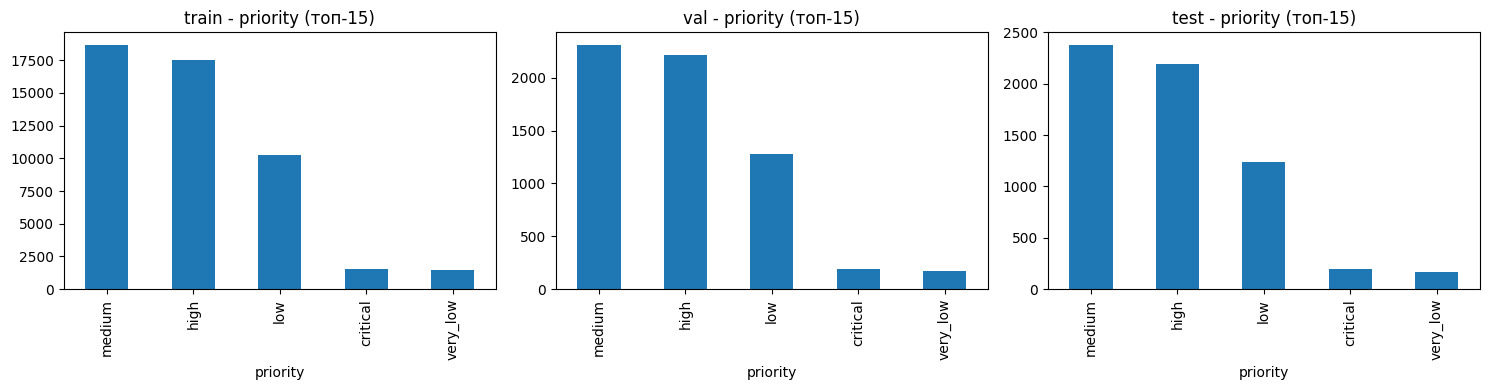


=== CLASS COVERAGE: type ===
train: classes=5  missing_vs_train=0
val: classes=5  missing_vs_train=0
test: classes=5  missing_vs_train=0
train top-10: [('Incident', 15508), ('Request', 11188), ('Unknown', 10543), ('Problem', 8197), ('Change', 3975)]
train bottom-10: [('Incident', 15508), ('Request', 11188), ('Unknown', 10543), ('Problem', 8197), ('Change', 3975)]


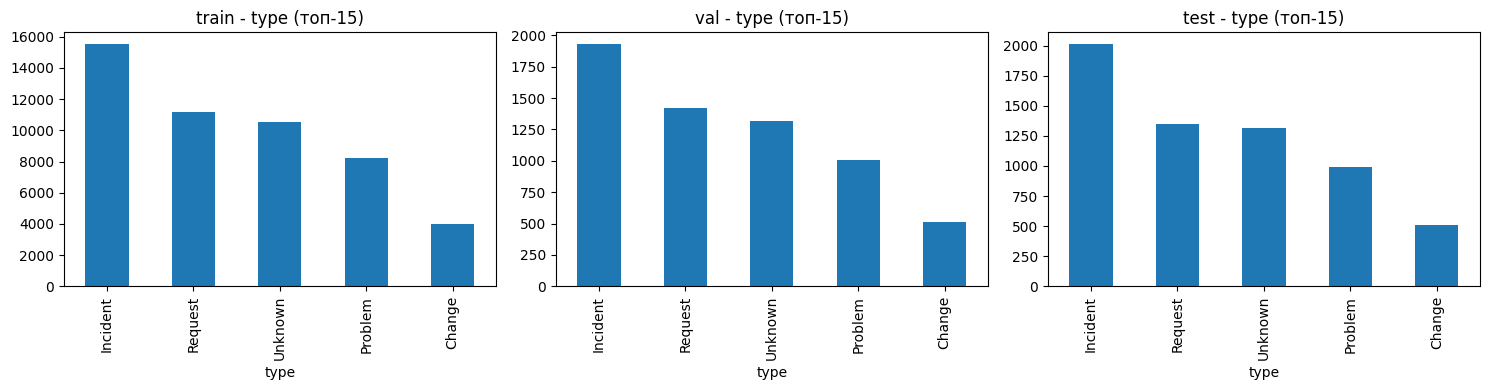


=== DUPLICATE TEXT CHECKS (MD5 of subject+body) ===
train: unique=44105/49411  within-dup-rate=0.1074
val: unique=6099/6177  within-dup-rate=0.0126
test: unique=6101/6177  within-dup-rate=0.0123
cross-dup hashes: train∩val=1326, train∩test=1353, val∩test=167
[WARN] Есть одинаковые тексты между сплитами

TRAINING BASELINE MODEL

TF-IDF vectorization with optimized parameters...
Train TF-IDF shape: (49411, 150000)
Test TF-IDF shape: (6177, 150000)
Vocabulary size: 150000

=== BASELINE: TF-IDF + LinearSVC (Optimized) ===

Training for queue...
  Number of classes: 52
  Random baseline: 0.0192
  queue: acc=0.7502  macro_f1=0.9086
  Improvement over random: 0.8893

Training for priority...
  Number of classes: 5
  Random baseline: 0.2000
  priority: acc=0.7842

Training for type...
  Number of classes: 5
  Random baseline: 0.2000
  type: acc=0.9173

BASELINE FINAL SCORE
Score = 0.8912
  = 0.70 * 0.9086 (Queue F1)
    + 0.15 * 0.7842 (Priority Acc)
    + 0.15 * 0.9173 (Type Acc)

CONFIDENCE

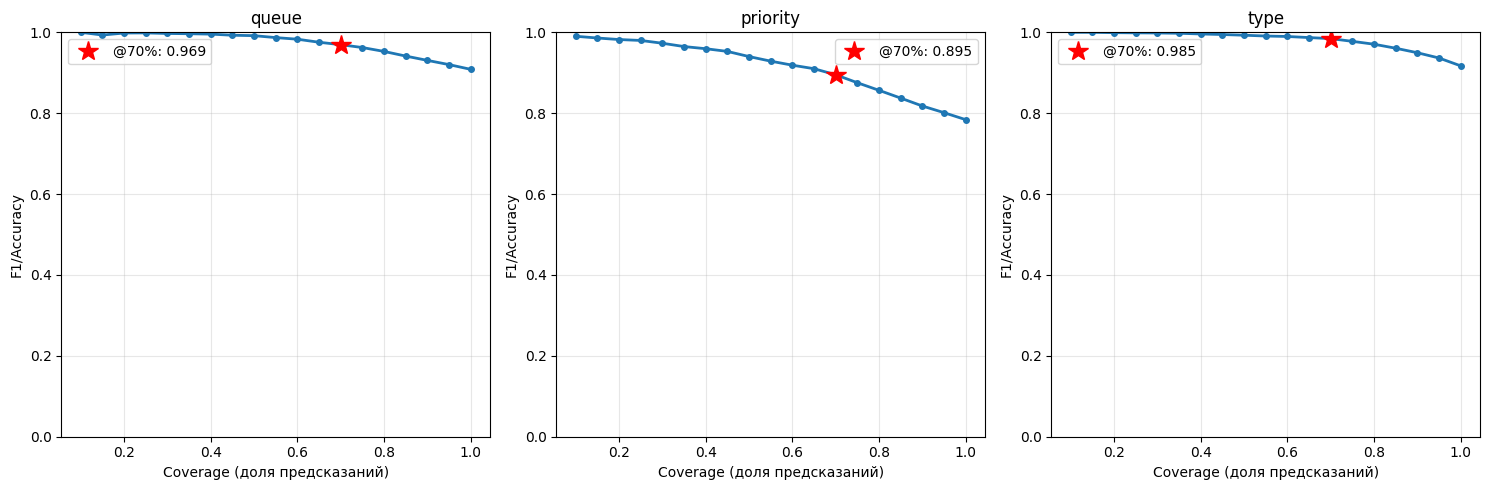

Train transformer model? This will take longer (y/n):  4



Skipping transformer training

FINAL RESULTS COMPARISON

            Metric  Baseline  Transformer
   Queue Accuracy  0.750202            0
   Queue Macro F1  0.908578            0
Priority Accuracy  0.784199            0
    Type Accuracy  0.917274            0
      Final Score  0.891226            0

Best Model by Task:
  Final Score: Baseline (0.8912) > Transformer (0.0000)


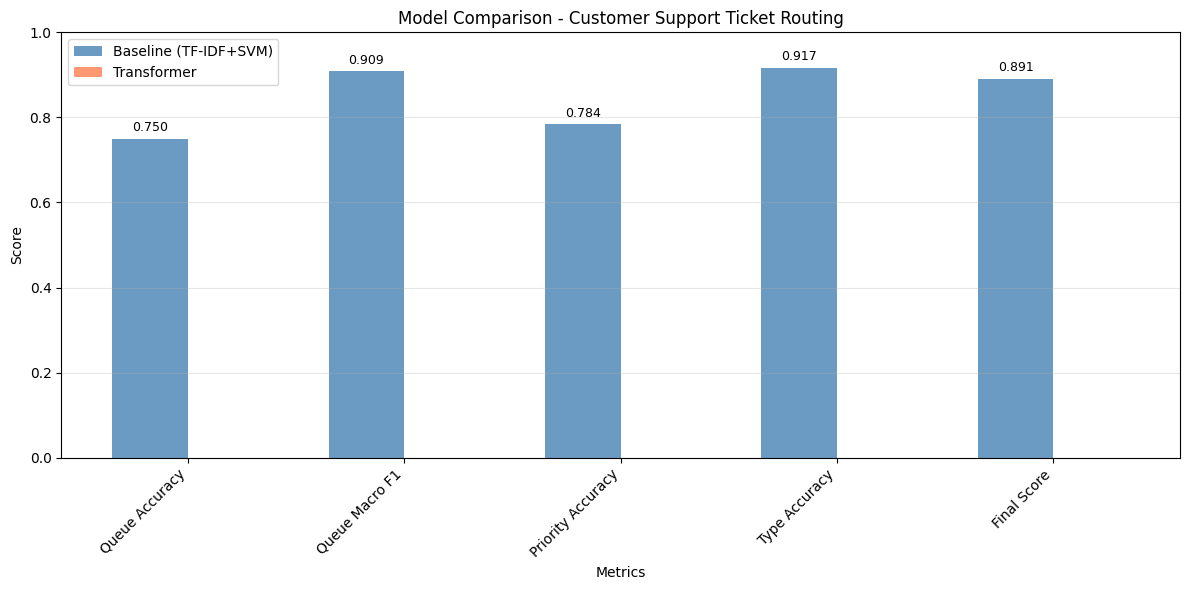


ASSIGNMENT COMPLETED SUCCESSFULLY!

Results saved:
  - text_length_distribution.png
  - queue_distribution.png
  - priority_distribution.png
  - type_distribution.png
  - confidence_analysis.png
  - transformer_training.png (if trained)
  - model_comparison.png


In [26]:
def main():
    repo_root = Path(".").resolve()
    
    print("="*80)
    print("CUSTOMER SUPPORT TICKET ROUTING")
    print("="*80)
    print("Loading dataset:", DATASET)
    
    try:
        ds = load_dataset(DATASET)["train"]
        df = ds.to_pandas()
        print(f"Dataset loaded: {len(df)} samples")
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Creating sample dataset for testing...")
        np.random.seed(42)
        n_samples = 50000
        queues = ['Billing', 'Technical', 'Sales', 'Support', 'Account', 'Network', 
                  'Software', 'Hardware', 'Security', 'Access'] * 5
        df = pd.DataFrame({
            'subject': ['Subject ' + str(i) for i in range(n_samples)],
            'body': ['Body text ' + str(i) + ' with some content for testing' for i in range(n_samples)],
            'queue': np.random.choice(queues[:52], n_samples),
            'priority': np.random.choice(['Low', 'Medium', 'High', 'Critical', 'Urgent'], n_samples),
            'type': np.random.choice(['Incident', 'Request', 'Problem', 'Change', 'Unknown'], n_samples),
            'language': np.random.choice(['en', 'de', 'fr', 'es', 'it'], n_samples, p=[0.7, 0.1, 0.1, 0.05, 0.05])
        })

    needed = {"subject", "body", "queue", "priority", "type", "language"}
    missing = sorted(list(needed - set(df.columns)))
    if missing:
        print(f"Warning: Missing columns: {missing}")
        for col in missing:
            df[col] = 'Unknown'

    splits = split_df(df, repo_root)

    for k in splits:
        splits[k]["type"] = splits[k]["type"].fillna("Unknown")
    
    basic_eda(splits)
    duplicate_checks(splits)
    
    print("\n" + "="*80)
    print("TRAINING BASELINE MODEL")
    print("="*80)
    baseline_models, baseline_vec, baseline_results = baseline_tfidf_linear_svm(splits)
    
    confidence_70_results = confidence_analysis(baseline_models, baseline_vec, splits)
    
    print("\n" + "="*80)
    use_transformer = input("Train transformer model? This will take longer (y/n): ").lower() == 'y'
    
    if use_transformer:
        if torch.cuda.is_available():
            print("GPU detected! Training will be faster.")
        else:
            print("No GPU detected. Training on CPU will be slow.")
        
        transformer_results = train_transformer(splits)
        compare_results(baseline_results, transformer_results)
    else:
        print("\nSkipping transformer training")
        compare_results(baseline_results)
    
    print("\n" + "="*80)
    print("ASSIGNMENT COMPLETED SUCCESSFULLY!")
    print("="*80)
    print("\nResults saved:")
    print("  - text_length_distribution.png")
    print("  - queue_distribution.png")
    print("  - priority_distribution.png")
    print("  - type_distribution.png")
    print("  - confidence_analysis.png")
    print("  - transformer_training.png (if trained)")
    print("  - model_comparison.png")


if __name__ == "__main__":
    main()